<a href="https://colab.research.google.com/github/Du-nara/ME421-Mechanical-Systems-Lab-A3/blob/main/Controls/E_20_388_Controls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 1 – Dynamic Model of the Twin Rotor System
---

**1. Modelling Assumption**

The twin rotor system behaves like a rigid body rotating about its center of mass.

Key assumptions:

*   The body is rigid (no deformation).
*   Motion considered is pure rotation.
*   Forces from rotors produce control torques.
*   External disturbances such as gravity or aerodynamic effects are uncontrolled torques.

**2. Define the Frames**

Spatial frame (fixed frame)

<center>𝐶=($𝑐_1,𝑐_2,𝑐_3$)</center>

Body frame (attached to rotor beam)

<center>B=($b_1​,b_2​,b_3$​)</center>

The body frame rotates relative to the spatial frame by an angle 𝜑.

**3. Orientation Representation**

The orientation of the body relative to the spatial frame is represented by a rotation matrix,

<center>R∈SO(3)</center>

where

$R^{T}R=I$ and  det(R) = 1

This matrix transforms body-frame vectors into spatial-frame vectors.

<center>$v_s​=Rv_b​$</center>

**4. Kinematics of the Rigid Body**

For a rigid body rotating with angular velocity
𝜔, the rotation matrix satisfies,

<center>$\dot{R}=\hat{\omega}$R</center>

where

<center>
$\hat{\omega} =
\begin{bmatrix}
0 & -\omega_3 & \omega_2 \\
\omega_3 & 0 & -\omega_1 \\
-\omega_2 & \omega_1 & 0
\end{bmatrix}
$</center>

and

<center>
$\omega =
\begin{bmatrix}
\omega_1 \\
\omega_2 \\
\omega_3
\end{bmatrix}
$</center>

**5. Angular Momentum of the System**

For a rigid body the angular momentum is,

<center>$π=I^{R}ω$</center>

where

$I^{R}$= inertia matrix expressed in spatial frame

Rearranging:

<center>$\omega = (I^R)^{-1}\pi$</center>

**6. Rotational Dynamics**

From Euler’s rotational dynamics,

<center>$\frac{d\pi}{dt} = \tau$</center>

where

𝜋= angular momentum

𝜏= total torque acting on the system

In the twin rotor system the torques are divided into,

<center>$\tau = \tau^e + \tau^u$</center>

where

$𝜏^𝑒$= external / constraint torque

$𝜏^u$= control torque generated by the rotors

Thus,

<center>$\dot{𝜋}= \tau^e + \tau^u$</center>

**7. Control Torque Generated by Rotors**

From the model provided:

<center>$\tau^u = R
\begin{bmatrix}
1 & 0 \\
0 & 0 \\
0 & 1
\end{bmatrix}
\begin{bmatrix}
\cos\alpha & -\cos\beta \\
\sin\alpha & -\sin\beta
\end{bmatrix}
\begin{bmatrix}
u_1 \\
u_2
\end{bmatrix}$</center>

**8. Constraint Torque**

The device cannot rotate about axis $b_2$.

Therefore a constraint torque appears:

<center>$\tau^e = R
\begin{bmatrix}
0 \\
T_2 \\
0
\end{bmatrix}$</center>

**9. Expression for the Constraint Moment**

<center>$T_2 = \mathbf{e}_2^{T}\left(\Omega \times I\Omega + I\dot{\Omega}\right)$</center>

where

$\Omega = R^{T}\omega$

**10. Final Dynamic Model**

Combining the kinematics and dynamics gives the model:

*Orientation dynamics*
<center>$\dot{R} = \hat{\omega} R$</center>

*Angular momentum dynamics*
<center>$
\dot{\pi} = \tau^e + \tau^u
$</center>

*Angular velocity relation*
<center>$
\omega = (I^R)^{-1}\pi
$</center>


This forms the intrinsic rigid body dynamic model used for the PID controller design.


# Task 2 – Simulate and animate the motion of the system

---


Step 1 – Import Required Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib as mpl

mpl.rcParams['animation.embed_limit'] = 50

Step 2 – Hat Operator

In [ ]:
def hat(w):
    return np.array([
        [0,-w[2],w[1]],
        [w[2],0,-w[0]],
        [-w[1],w[0],0]
    ])

Step 3 – Inertia Matrix (Body Frame)

In [ ]:
I = np.diag([0.02,0.02,0.04])

Step 4 – Simulation Parameters

In [ ]:
dt = 0.03
T = 10
steps = int(T/dt)


Step 5 - Simulation Function

In [ ]:
def simulate(control_function):

    R = np.eye(3)
    pi = np.array([0.,0.,0.])

    R_history = []

    for k in range(steps):

        t = k*dt

        # Spatial inertia
        IR = R @ I @ R.T

        # Angular velocity
        w = np.linalg.inv(IR) @ pi

        # Orientation derivative
        Rdot = hat(w) @ R

        # Control torque
        tau = control_function(t)

        # Momentum derivative
        pidot = tau

        # Euler integration
        R = R + Rdot*dt
        pi = pi + pidot*dt

        R_history.append(R.copy())

    return np.array(R_history)

Step 6 - Control Inputs

Vertical Axis Spin

In [ ]:
def vertical_spin(t):
    return np.array([0,0,0.05])

Horizontal Swing

In [ ]:
def horizontal_swing(t):
    return np.array([0.05*np.sin(t),0,0])

Step 7 - Run Simulation

In [ ]:
R_spin = simulate(vertical_spin)
R_swing = simulate(horizontal_swing)

Step 8 - Animation Function

In [ ]:
def animate_motion(R_history):

    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    def update(frame):

        ax.clear()

        R = R_history[frame]

        b1 = R[:,0]
        b2 = R[:,1]
        b3 = R[:,2]

        ax.quiver(0,0,0,*b1,color='r',label='b1')
        ax.quiver(0,0,0,*b2,color='g',label='b2')
        ax.quiver(0,0,0,*b3,color='b',label='b3')

        ax.set_xlim([-1,1])
        ax.set_ylim([-1,1])
        ax.set_zlim([-1,1])

        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")

        ax.set_title("Rigid Body Orientation")

    ani = FuncAnimation(fig, update, frames=len(R_history[::3]), interval=40)

    return HTML(ani.to_jshtml())

Step 9 - Show Animations

Vertical Spin

In [ ]:
#animate_motion(R_spin)

Horizontal Swing

In [ ]:
#animate_motion(R_swing)

# Task 3 – Derivation of a PID controller using error dynamics

---

**Step 1 — Define Reference Motion**

Given:
*   Desired orientation: $𝑅_𝑟(𝑡)$
*   Desired angular velocity:

<center>$\hat{\omega}_r = \dot{R}_r R_r^{T}$</center>

**Step 2 — Define Reference Angular Momentum**
<center>${\pi}_r = R_r I R_r^{T} {\omega}_r$</center>

**Step 3 — Define Configuration Error**

<center>$R_e = R_r R^{T}$</center>

**Step 4 — Define Error Angular Velocity**

Start from:

<center>$\hat{\omega}_e = \dot{R}_e R_e^{T}$</center>

Differentiate:
<center>$R_e = R_r R^{T}$</center>

<center>$\dot{R}_e = \dot{R}_r R^{T} + R_r \dot{R}^{T}$</center>

Substitute:
<center>$\dot{R}_r = \hat{\boldsymbol{\omega}}_r R_r$, $\dot{R} = \hat{\boldsymbol{\omega}} R$</center>

<center>$\dot{R}^{T} = - R^{T} \hat{\boldsymbol{\omega}}$</center>

So:
<center>$\dot{R}_e = \hat{\boldsymbol{\omega}}_r R_e - R_e \hat{\boldsymbol{\omega}}$</center>

Multiply by $R_e^{T}$:

<center>$\hat{\omega}_e = \hat{\omega}_r - R_e \hat{\omega} R_e^{T}$</center>



Therefore:

<center>$\hat{\omega}_e = \hat{\omega}_r - \widehat{R_e \boldsymbol{\omega}}$</center>

Hence,
<center>${\omega}_e = {\omega}_r - R_e {\omega}$</center>

**Step 5 — Define Momentum Error**
<center>${\pi}_e = R I R^{T} {\omega}_e$</center>

Substitute ${\omega}_e$:
<center>${\pi}_e = R I R^{T} \left( {\omega}_r - R_e {\omega} \right)$</center>

Split:
<center>${\pi}_e = R I R^{T} {\omega}_r - R I R^{T} R_e {\omega}$</center>

Using identities:
<center>$R I R^{T} {\omega} = {\pi}$,

$R I R^{T} {\omega}_r = R_e^{T} {\pi}_r$</center>

So:
<center>${\pi}_e = R_e^{T} {\pi}_r - {\pi}$</center>

**Step 6 — Differentiate Momentum Error**
<center>${\pi}_e = R_e^{T} {\pi}_r - {\pi}$</center>

Differentiate:

<center>$\dot{{\pi}}_e = \dot{R}_e^{T} {\pi}_r + R_e^{T} \dot{{\pi}}_r - \dot{{\pi}}$</center>

Using identity:

<center>$\dot{R}_e^{T} = - \hat{{\omega}}_e R_e^{T}$</center>

So:
<center>$\dot{{\pi}}_e = - \hat{{\omega}}_e R_e^{T} {\pi}_r + R_e^{T} \dot{{\pi}}_r - \dot{{\pi}}$</center>

Rearrange:
<center>$\dot{{\pi}}_e = R_e^{T} \left( \dot{{\pi}}_r - {\omega}_e \times {\pi}_r \right) - \dot{{\pi}}$</center>

**Step 7 — Substitute System Dynamics**
From Task 1:


**Step 8 — Expand Reference Term**

But:
<center>$\dot{{\pi}}_r = R_r\dot{\Pi}_r$</center>

After simplification:
<center>$\dot{\pi}_e=(R\dot{\Pi}_r+\omega\times R_e^T\pi_r)-\dot{\pi}
$</center>

**Step 9 — Final Error Dynamics**

Orientation error:
<center>$\dot{R}_e = \hat{{\omega}}_e R_e$</center>

Momentum error:
<center>$\dot{{\pi}}_e
=(R\dot{\Pi}_r+\omega\times R_e^T\pi_r)
- {\tau}_u - {\tau}_e$</center>

**Step 10 — Design PID Controller**

Requirement:

<center>$R_e \to I, \quad \boldsymbol{\pi}_e \to \mathbf{0}$</center>

Choose control:

<center>$\tau_u = -K_p e_R - K_d \omega_e - K_I e_{I_R} + \left( R \dot{\Pi}_r + \omega \times R e_T \pi_r \right)$</center>

where

<center>$\mathbf{e}_{IR} = \int \mathbf{e}_R \, dt$</center>

Substitute into error dynamics:

<center>$\dot{{\pi}}_e
=
- K_p \mathbf{e}_R
- K_d {\omega}_e
- K_I \mathbf{e}_{IR}
- {\tau}_e$</center>

*Note: Feedforward terms cancel reference dynamics.*

So system behaves like a stable PID system.



# Simulation

---






/tmp/ipykernel_1514/1346371156.py:66: RuntimeWarning: overflow encountered in matmul
  IR = R @ I @ R.T


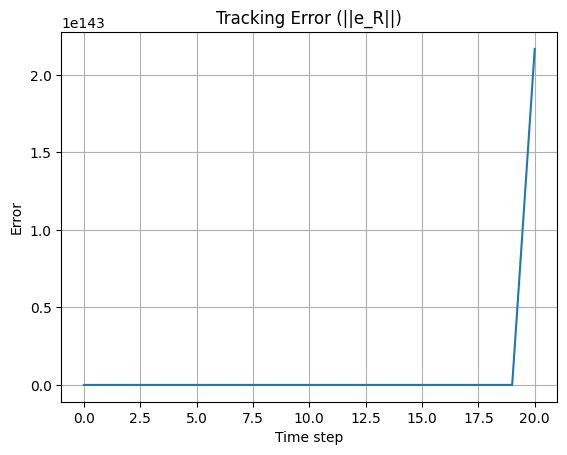

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Utility functions
# ----------------------------
def hat(w):
    return np.array([
        [0, -w[2], w[1]],
        [w[2], 0, -w[0]],
        [-w[1], w[0], 0]
    ])

# ----------------------------
# Reference trajectory
# ----------------------------
def reference(t):
    theta = 0.5 * np.sin(t)
    dtheta = 0.5 * np.cos(t)
    ddtheta = -0.5 * np.sin(t)

    Rr = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0, 0, 1]
    ])

    wr = np.array([0, 0, dtheta])
    wdot_r = np.array([0, 0, ddtheta])

    return Rr, wr, wdot_r

# ----------------------------
# Parameters
# ----------------------------
dt = 0.02
T = 10
steps = int(T/dt)

I = np.diag([0.02, 0.02, 0.04])

Kp = np.diag([5,5,5])
Kd = np.diag([2,2,2])
Ki = np.diag([1,1,1])

# ----------------------------
# Initial conditions
# ----------------------------
R = np.eye(3)
pi = np.array([0.0,0.0,0.0])
eIR = np.zeros(3)

error_history = []

# ----------------------------
# Simulation loop
# ----------------------------
for k in range(steps):

    t = k * dt

    # Reference
    Rr, wr, wdot_r = reference(t)

    # Current state
    IR = R @ I @ R.T
    w = np.linalg.inv(IR) @ pi

    # Errors
    Re = Rr @ R.T
    we = wr - Re @ w

    # eR
    eR_mat = np.eye(3) @ Re - Re.T @ np.eye(3)
    eR = np.array([eR_mat[2,1], eR_mat[0,2], eR_mat[1,0]])

    # Integral
    eIR += eR * dt

    # Reference momentum
    IR_r = Rr @ I @ Rr.T
    pi_r = IR_r @ wr

    # Body frame quantities
    Omega_r = Rr.T @ wr
    Omega_dot_r = Rr.T @ wdot_r

    Pi_r = I @ Omega_r
    Pi_dot_r = I @ Omega_dot_r + np.cross(Omega_r, Pi_r)

    # Feedforward
    feedforward = R @ Pi_dot_r + np.cross(w, Re.T @ pi_r)

    # Control
    tau = -Kp @ eR - Kd @ we - Ki @ eIR + feedforward

    # Dynamics
    Rdot = hat(w) @ R
    pidot = tau

    R = R + Rdot * dt
    pi = pi + pidot * dt

    # Store error
    error_history.append(np.linalg.norm(eR))

# ----------------------------
# Plot
# ----------------------------
plt.figure()
plt.plot(error_history)
plt.title("Tracking Error (||e_R||)")
plt.xlabel("Time step")
plt.ylabel("Error")
plt.grid()
plt.show()